In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('insurance.csv')
df

,Id,age,gender,bmi,bloodpressure,diabetic,children,smoker,region,claim
0,1,39.0,male,23.2,91,Yes,0,No,southeast,1121.87
1,2,24.0,male,30.1,87,No,0,No,southeast,1131.51
2,3,NaN,male,33.3,82,Yes,0,No,southeast,1135.94
3,4,NaN,male,33.7,80,No,0,No,northwest,1136.40
4,5,NaN,male,34.1,100,No,0,No,northwest,1137.01
...,...,...,...,...,...,...,...,...,...,...
1335,1336,44.0,female,35.5,88,Yes,0,Yes,northwest,55135.40
1336,1337,59.0,female,38.1,120,No,1,Yes,northeast,58571.07
1337,1338,30.0,male,34.5,91,Yes,3,Yes,northwest,60021.40
1338,1339,37.0,male,30.4,106,No,0,Yes,southeast,62592.87


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1340 entries, 0 to 1339
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1340 non-null   int64  
 1   age            1335 non-null   float64
 2   gender         1340 non-null   object 
 3   bmi            1340 non-null   float64
 4   bloodpressure  1340 non-null   int64  
 5   diabetic       1340 non-null   object 
 6   children       1340 non-null   int64  
 7   smoker         1340 non-null   object 
 8   region         1337 non-null   object 
 9   claim          1340 non-null   float64
dtypes: float64(3), int64(3), object(4)
memory usage: 104.8+ KB


In [4]:
df.describe()

,Id,age,bmi,bloodpressure,children,claim
count,1340.000000,1335.000000,1340.000000,1340.000000,1340.000000,1340.000000
mean,670.500000,38.078652,30.668955,94.157463,1.093284,13252.745642
std,386.968991,11.102924,6.106735,11.434712,1.205334,12109.609288
min,1.000000,18.000000,16.000000,80.000000,0.000000,1121.870000
25%,335.750000,29.000000,26.275000,86.000000,0.000000,4719.685000
50%,670.500000,38.000000,30.400000,92.000000,1.000000,9369.615000
75%,1005.250000,47.000000,34.700000,99.000000,2.000000,16604.305000
max,1340.000000,60.000000,53.100000,140.000000,5.000000,63770.430000


In [5]:
sns.set(style='whitegrid', palette='Set2', font_scale= 1.1)

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df.isna().sum()

Id               0
age              5
gender           0
bmi              0
bloodpressure    0
diabetic         0
children         0
smoker           0
region           3
claim            0
dtype: int64

In [8]:
df.dropna(inplace = True)
df.isna().sum().sum()

np.int64(0)

In [9]:
df.shape

(1332, 10)

In [10]:
df.describe(include='all')

,Id,age,gender,bmi,bloodpressure,diabetic,children,smoker,region,claim
count,1332.000000,1332.000000,1332,1332.000000,1332.000000,1332,1332.000000,1332,1332,1332.000000
unique,NaN,NaN,2,NaN,NaN,2,NaN,2,4,NaN
top,NaN,NaN,male,NaN,NaN,No,NaN,No,southeast,NaN
freq,NaN,NaN,670,NaN,NaN,695,NaN,1058,442,NaN
mean,674.474474,38.086336,NaN,30.658333,94.189189,NaN,1.099850,NaN,NaN,13325.246426
std,384.703785,11.112804,NaN,6.118967,11.445173,NaN,1.205958,NaN,NaN,12109.620712
min,1.000000,18.000000,NaN,16.000000,80.000000,NaN,0.000000,NaN,NaN,1121.870000
25%,341.750000,29.000000,NaN,26.200000,86.000000,NaN,0.000000,NaN,NaN,4760.157500
50%,674.500000,38.000000,NaN,30.350000,92.000000,NaN,1.000000,NaN,NaN,9412.965000
75%,1007.250000,47.000000,NaN,34.725000,99.000000,NaN,2.000000,NaN,NaN,16781.327500


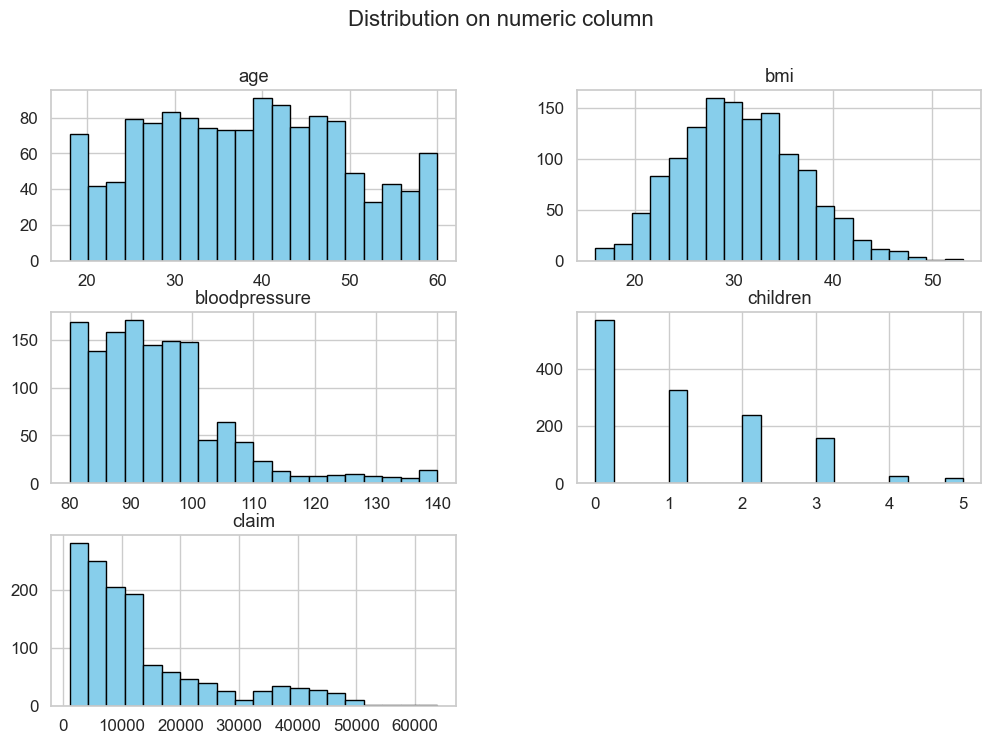

In [11]:
numeric_columns = ['age', 'bmi', 'bloodpressure', 'children','claim']
df[numeric_columns].hist(bins=20, figsize=(12, 8), color= 'skyblue', edgecolor='black')
plt.suptitle('Distribution on numeric column', fontsize=16)
plt.show()

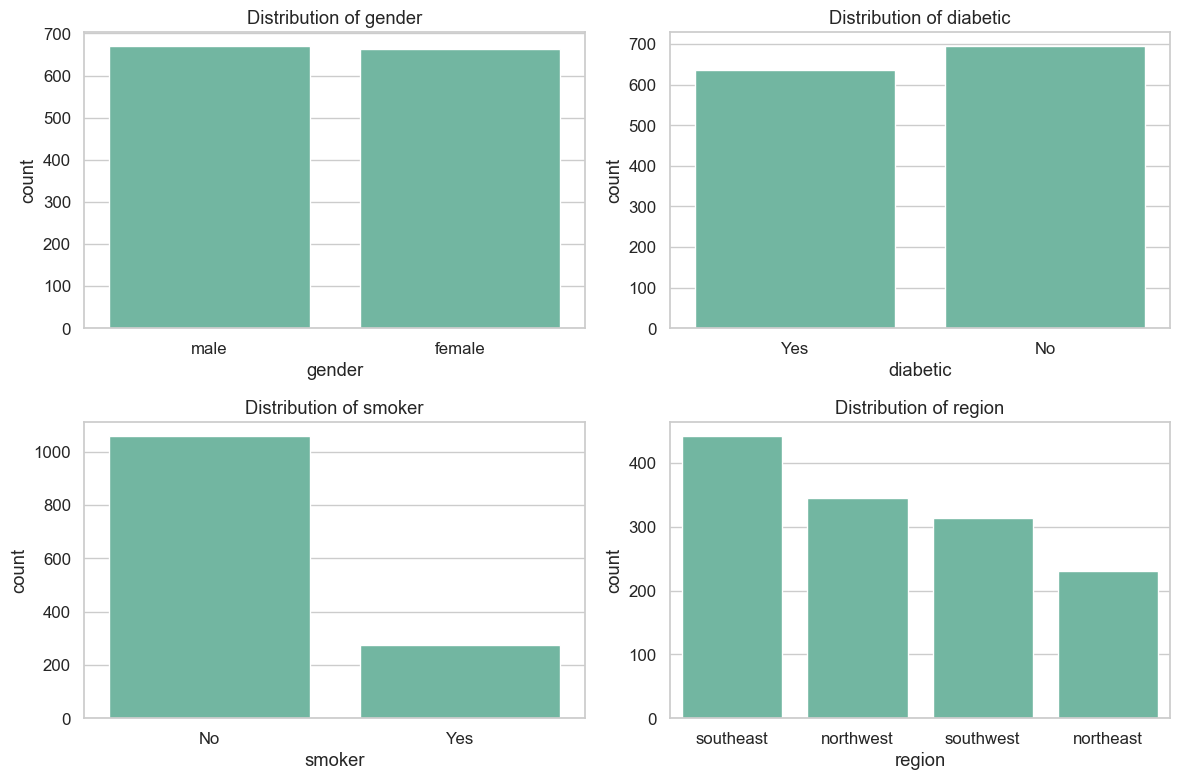

In [12]:
cat_cols = ['gender', 'diabetic', 'smoker', 'region']

plt.figure(figsize=(12,8))

for i, col in enumerate(cat_cols, 1):
    plt.subplot(2, 2, i)
    sns.countplot(data=df, x=col)
    plt.title(f'Distribution of {col}')

plt.tight_layout()
plt.show()

In [13]:
df.groupby(['gender', 'smoker'])['claim'].mean().round(2)

gender  smoker
female  No         8762.30
        Yes       30679.00
male    No         8169.25
        Yes       33042.01
Name: claim, dtype: float64

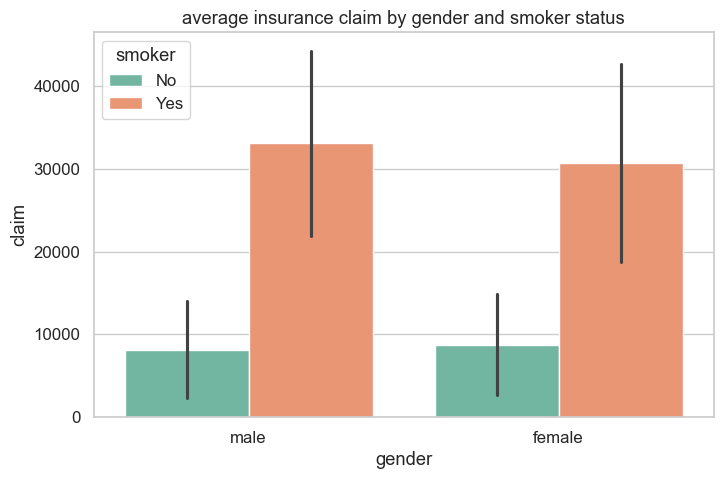

In [14]:
plt.figure(figsize=(8,5))
sns.barplot(data = df, x='gender', y='claim', hue='smoker', estimator='mean', errorbar='sd')
plt.title("average insurance claim by gender and smoker status")
plt.show()

In [15]:
region_diabetic_claims = df.groupby(['region', 'diabetic'])['claim'].mean().unstack()
region_diabetic_claims

diabetic,No,Yes
region,,
northeast,16966.861455,16818.302231
northwest,11442.831842,12224.958000
southeast,13578.717200,12574.093226
southwest,13069.907824,12313.739167


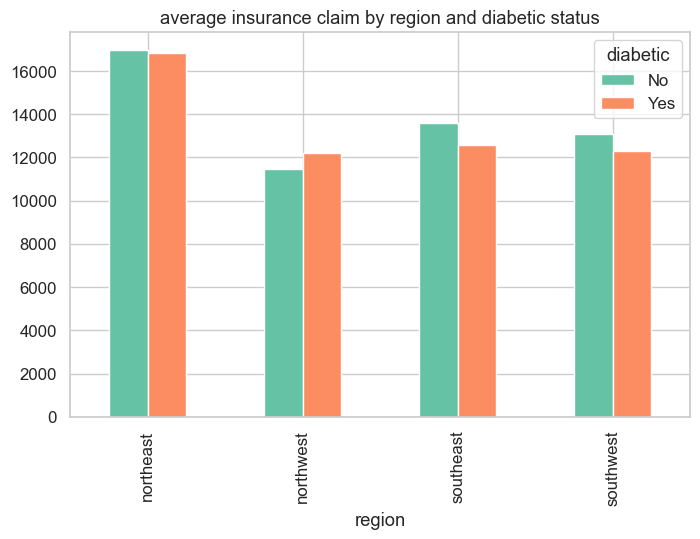

In [16]:
region_diabetic_claims.plot(kind = 'bar', figsize=(8,5))
plt.title("average insurance claim by region and diabetic status")
plt.show()

In [17]:
pivot_table = pd.pivot_table(df, values='claim', index='region', columns='smoker', aggfunc='mean')
pivot_table

smoker,No,Yes
region,,
northeast,11666.112195,29673.536269
northwest,8076.203415,30192.002759
southeast,7444.144872,34844.997253
southwest,8294.754102,32269.064138


In [18]:
pivot_table = pd.pivot_table(df, values='claim', index='children', columns='diabetic', aggfunc='mean')
pivot_table

diabetic,No,Yes
children,,
0,12967.395398,11985.289857
1,12730.455810,12732.055724
2,15567.767583,14579.360417
3,13807.612892,17091.258649
4,14106.630000,13573.352500
5,8519.043636,9205.594286


In [19]:
df[numeric_columns].corr()

,age,bmi,bloodpressure,children,claim
age,1.000000,-0.042152,-0.060322,-0.026208,-0.028636
bmi,-0.042152,1.000000,0.144977,0.013719,0.199945
bloodpressure,-0.060322,0.144977,1.000000,-0.034356,0.531263
children,-0.026208,0.013719,-0.034356,1.000000,0.064149
claim,-0.028636,0.199945,0.531263,0.064149,1.000000


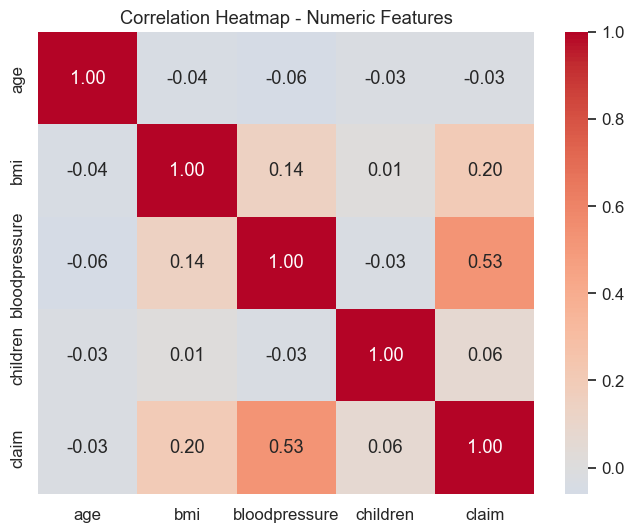

In [20]:
plt.figure(figsize=(8,6))
sns.heatmap(df[numeric_columns].corr(), annot=True, cmap='coolwarm', fmt='.2f', center=0)
plt.title('Correlation Heatmap - Numeric Features')
plt.show()

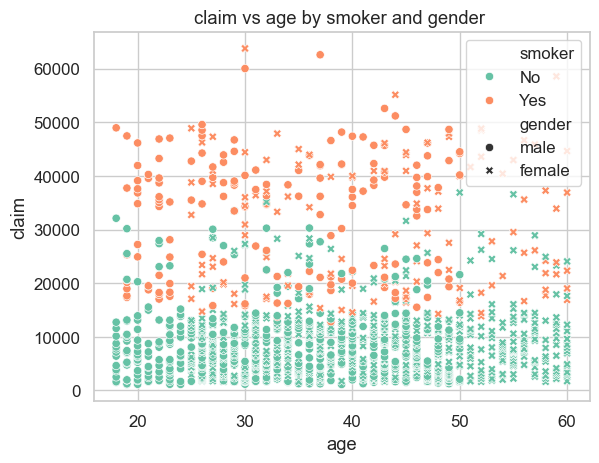

In [21]:
sns.scatterplot(data=df, x='age', y='claim', hue='smoker' , style='gender')
plt.title('claim vs age by smoker and gender ')
plt.show()

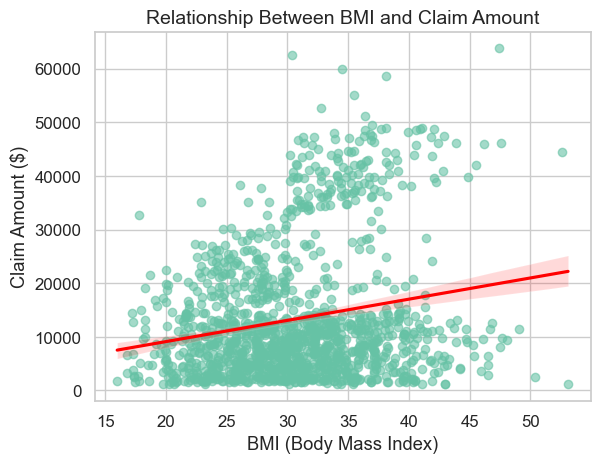

In [22]:
sns.regplot(data=df, x='bmi', y='claim', scatter_kws={'alpha':0.6}, line_kws={'color':'red'})
plt.title('Relationship Between BMI and Claim Amount', fontsize=14)
plt.xlabel('BMI (Body Mass Index)')
plt.ylabel('Claim Amount ($)')
plt.show()

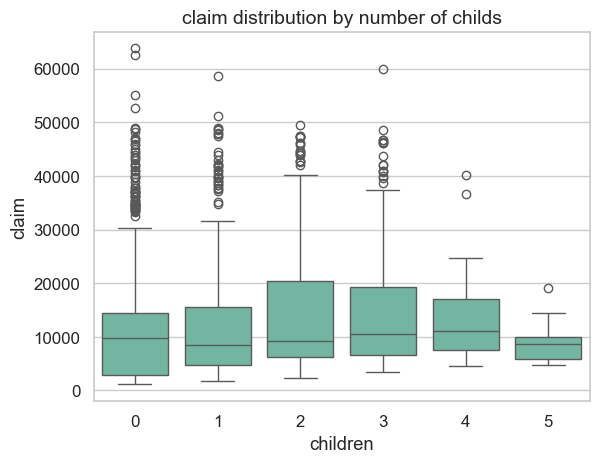

In [23]:
sns.boxplot(data = df,  x='children', y='claim')
plt.title('claim distribution by number of childs', fontsize=14)
plt.show()

In [24]:
df['age_group'] = pd.cut(df['age'], bins=[0, 18, 30, 45, 60, 100], labels=['<18','18-30','31-45','46-60','61-100'])
df['age_group'].value_counts()

age_group
31-45     553
46-60     383
18-30     380
<18        16
61-100      0
Name: count, dtype: int64

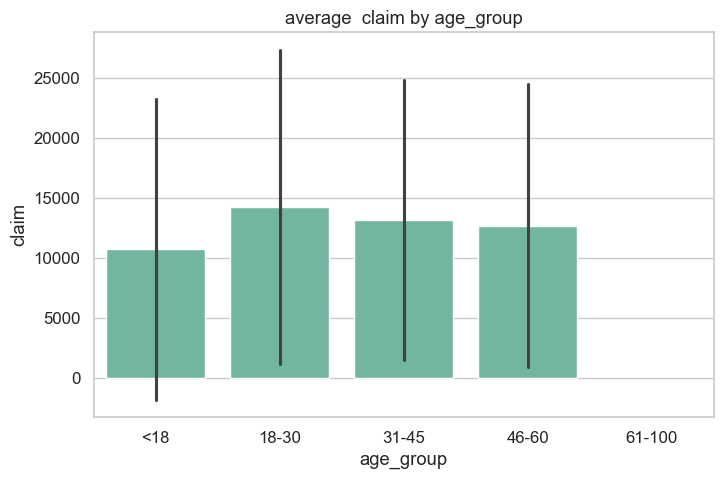

In [25]:
plt.figure(figsize=(8,5))
sns.barplot(data = df, x='age_group', y='claim', estimator='mean', errorbar='sd')
plt.title("average  claim by age_group")
plt.show()

In [26]:
df['bmi_category'] = pd.cut(df['bmi'], bins=[0, 18.5, 24.9, 29.9, 100], labels=['Underweight','Normal','Overweight','Obese'])
df['bmi_category'].value_counts()

bmi_category
Obese          702
Overweight     387
Normal         222
Underweight     21
Name: count, dtype: int64

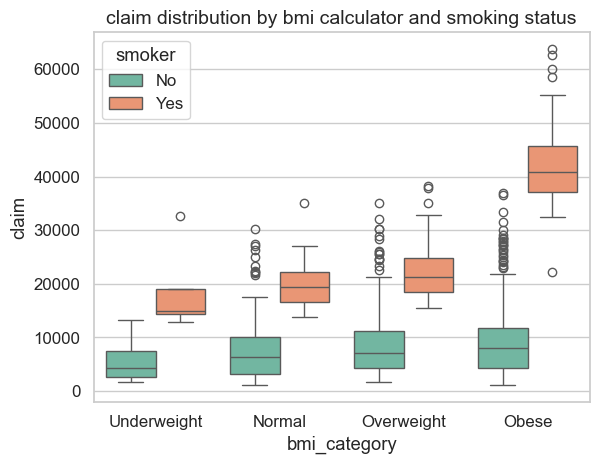

In [27]:
sns.boxplot(data = df,  x='bmi_category', y='claim', hue='smoker')
plt.title('claim distribution by bmi calculator and smoking status', fontsize=14)
plt.show()

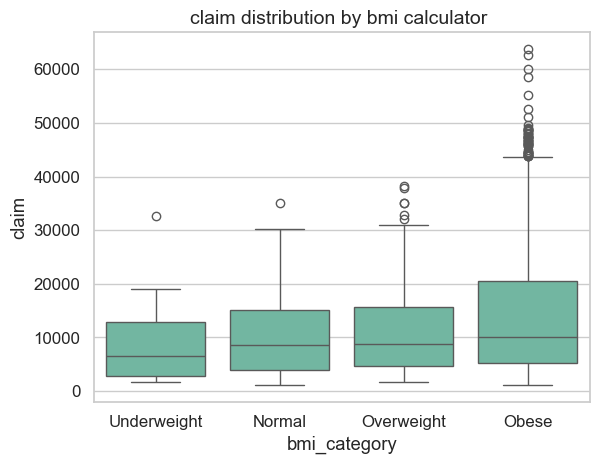

In [28]:
sns.boxplot(data = df,  x='bmi_category', y='claim',)
plt.title('claim distribution by bmi calculator ', fontsize=14)
plt.show()

In [29]:
region_stats = df.groupby('region').agg(smoker_rate=('smoker', lambda x: (x=='Yes').mean() * 100),   mean_claim=('claim', 'mean')).reset_index()
region_stats

,region,smoker_rate,mean_claim
0,northeast,29.004329,16889.044719
1,northwest,16.811594,11794.221855
2,southeast,20.588235,13085.496833
3,southwest,18.471338,12723.129841


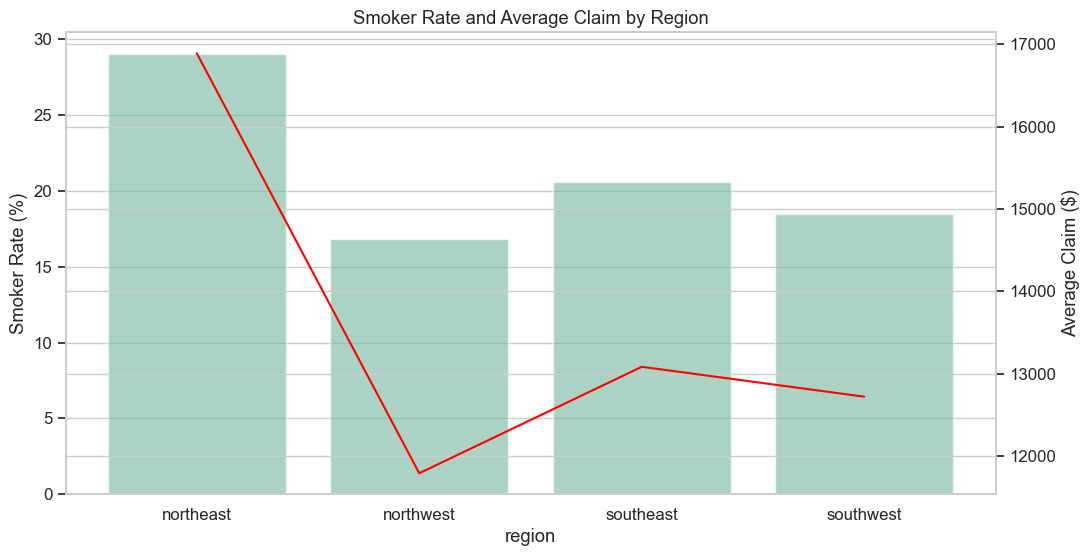

In [30]:
fig, ax1 = plt.subplots(figsize=(12,6))  # Single figure, primary axis

# LEFT Y-AXIS: Smoker Rate (%)
sns.barplot(data=region_stats, x='region', y='smoker_rate', ax=ax1, alpha=0.6)
ax1.set_ylabel('Smoker Rate (%)')

# RIGHT Y-AXIS: Mean Claim ($)
ax2 = ax1.twinx()  # Creates SECOND Y-axis sharing same X-axis
sns.lineplot(data=region_stats, x='region', y='mean_claim', ax=ax2, color='red', markers='O' )
ax2.set_ylabel('Average Claim ($)')

plt.title('Smoker Rate and Average Claim by Region')
plt.show()


## preprocessing

In [31]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
import joblib

In [32]:
df.columns

Index(['Id', 'age', 'gender', 'bmi', 'bloodpressure', 'diabetic', 'children',
       'smoker', 'region', 'claim', 'age_group', 'bmi_category'],
      dtype='object')

In [53]:
X = df[[ 'age', 'gender', 'bmi', 'bloodpressure', 'diabetic', 'children', 'smoker']]
y =df['claim']

In [54]:
X

,age,gender,bmi,bloodpressure,diabetic,children,smoker
0,39.0,male,23.2,91,Yes,0,No
1,24.0,male,30.1,87,No,0,No
7,19.0,male,41.1,100,No,0,No
8,20.0,male,43.0,86,No,0,No
9,30.0,male,53.1,97,No,0,No
...,...,...,...,...,...,...,...
1335,44.0,female,35.5,88,Yes,0,Yes
1336,59.0,female,38.1,120,No,1,Yes
1337,30.0,male,34.5,91,Yes,3,Yes
1338,37.0,male,30.4,106,No,0,Yes


In [55]:
y

0        1121.87
1        1131.51
7        1146.80
8        1149.40
9        1163.46
          ...   
1335    55135.40
1336    58571.07
1337    60021.40
1338    62592.87
1339    63770.43
Name: claim, Length: 1332, dtype: float64

<Axes: >

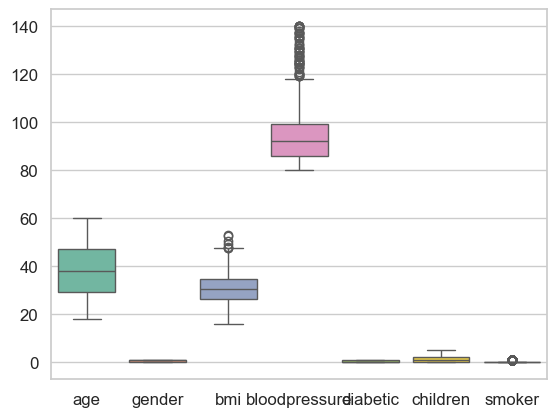

In [85]:
sns.boxplot(data = X)


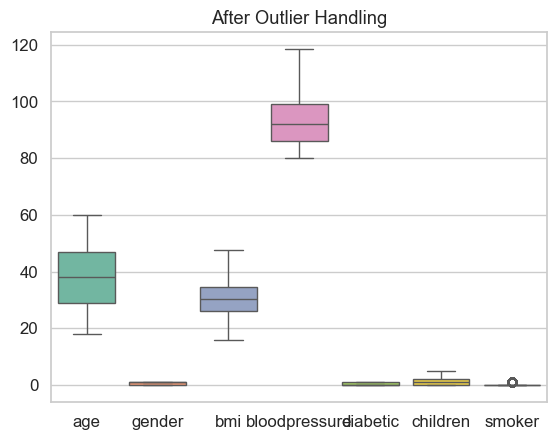

In [88]:
X_outlier_handled = X.copy()

for col in ['bmi', 'bloodpressure']:
    Q1 = X[col].quantile(0.25)
    Q3 = X[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    X_outlier_handled[col] = X[col].clip(lower_bound, upper_bound)
sns.boxplot(data=X_outlier_handled)
plt.title("After Outlier Handling")
plt.show()


<Axes: >

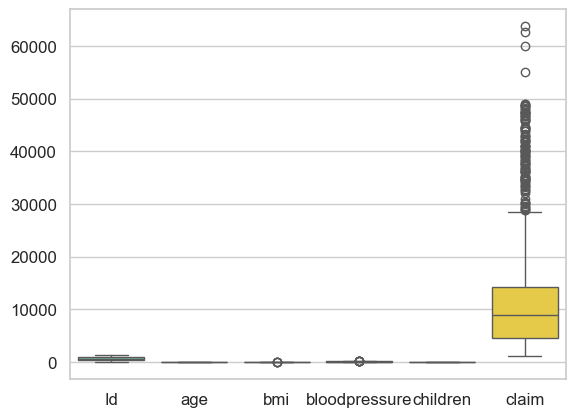

In [89]:
sns.boxplot(data = df_clean)


In [90]:
cat_cols = ['gender', 'diabetic', 'smoker']
label_encoders = {}

In [91]:
label_encoders = {}  # Initialize dictionary
for col in cat_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    label_encoders[col] = le
    joblib.dump(le, f"label_encoder_{col}.pkl")  # Save each encoder


C:\Users\omalb\AppData\Local\Temp\ipykernel_19236\2430817273.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[col] = le.fit_transform(X[col])
C:\Users\omalb\AppData\Local\Temp\ipykernel_19236\2430817273.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[col] = le.fit_transform(X[col])
C:\Users\omalb\AppData\Local\Temp\ipykernel_19236\2430817273.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

Se

In [92]:
label_encoders['gender']

LabelEncoder()

In [93]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)



In [94]:
num_cols = ['age', 'bmi', 'bloodpressure', 'children']
scaler = StandardScaler()


In [95]:
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])  # transform only, no fit

In [96]:
joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']

In [97]:
print(X_train.shape, y_train.shape)

(1065, 7) (1065,)


In [98]:
print(X_test.shape, y_test.shape)

(267, 7) (267,)


## model trainning

In [99]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import GridSearchCV


In [100]:
def evaluate_model(model, X_train, X_test, y_train, y_test):
    y_pred = model.predict(X_test)          # Test predictions
    r2 = r2_score(y_test, y_pred)           # R²: 0.85+ = excellent
    mae = mean_absolute_error(y_test, y_pred) # Avg $ error per prediction
    rmse = np.sqrt(mean_squared_error(y_test, y_pred)) # $ scale error
    return {"R²": r2, "MAE": mae, "RMSE": rmse}

In [101]:
models = {
    'LinearRegression': LinearRegression(),
    'RandomForest': RandomForestRegressor(n_estimators=100, random_state=42),
    'XGBoost': XGBRegressor(n_estimators=100, random_state=42),
    'GradientBoosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
    'SVR': SVR()
}
results = {}

In [102]:
best_poly_model = None
best_poly_score = -np.inf

for degree in [2,3]:
    poly = PolynomialFeatures(degree=degree)
    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)
    
    poly_lr = LinearRegression().fit(X_train_poly, y_train)
    score = poly_lr.score(X_test_poly, y_test)  # R²
    
    if score > best_poly_score:
        best_poly_score = score
        best_poly_model = (degree, poly, poly_lr)

degree, poly, poly_lr = best_poly_model
results[f'Polinomial Regression(degree = {degree})'] = evaluate_model(poly_lr, poly.fit_transform(X_train), poly.transform(X_test), y_train, y_test)



In [103]:
for name, model in models.items():
    model.fit(X_train, y_train)
    results[name] = evaluate_model(model, X_train, X_test, y_train, y_test)

results_df = pd.DataFrame(results).T
print(results_df.sort_values('RMSE'))

                                         R²          MAE          RMSE
GradientBoosting                   0.831256  3849.462405   4931.692512
RandomForest                       0.800918  4096.934536   5356.698106
XGBoost                            0.792397  4174.642964   5470.135090
Polinomial Regression(degree = 2)  0.775781  4426.321815   5684.827554
LinearRegression                   0.718640  5034.263199   6368.137982
SVR                               -0.101856  8170.911909  12602.127355


In [104]:
param_grid = {
    'n_estimators': [200, 300, 400],
    'max_depth': [3, 4, 5],
    'learning_rate': [0.05, 0.1, 0.15],
    'subsample': [0.8, 0.9],
    'colsample_bytree': [0.8, 0.9]
}

xgb = XGBRegressor(random_state=42)
grid = GridSearchCV(
    xgb, param_grid, 
    cv=5, 
    scoring='neg_mean_squared_error',
    n_jobs=-1,  # Use all CPU cores
    verbose=1
)

grid.fit(X_train, y_train)
print("Best params:", grid.best_params_)
print("CV RMSE:", np.sqrt(-grid.best_score_))


Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best params: {'colsample_bytree': 0.9, 'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.8}
CV RMSE: 5523.031768861032
